In [1]:
#################################################################################################
# Import necessary libraries
#################################################################################################
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.inspection import PartialDependenceDisplay
from time import time
from pprint import pprint
%matplotlib inline
from matplotlib import pyplot
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style('darkgrid')
from scipy import stats
from scipy.stats import norm, skew

import lime
import lime.lime_tabular


In [2]:
#################################################################################################
# Import data
#################################################################################################
Data_DF = pd.read_excel("MKGPC_dummy.xlsx")

In [3]:
#################################################################################################
# Prepare engineered features
#################################################################################################
#Data_DF['W/B Ratio'] = Data_DF['Water']/(Data_DF['Cement'] + Data_DF['Blast Furnace Slag'] + Data_DF['Fly Ash'])

#Data_DF['BFS/W Ratio'] = Data_DF['Blast Furnace Slag']/Data_DF['Water']

#Data_DF['FASH/W Ratio'] = Data_DF['Fly Ash']/Data_DF['Water']

#Data_DF['CA/B Ratio'] = Data_DF['Coarse Aggregate']/(Data_DF['Cement'] + Data_DF['Blast Furnace Slag'] + Data_DF['Fly Ash'])

#Data_DF['CA/FA Ratio'] = Data_DF['Coarse Aggregate']/Data_DF['Fine Aggregate']

In [29]:
#################################################################################################
# Create an array of features for model development
#################################################################################################
Feature_Names = ['MK','SHS','SHSM','SSS','W','W/S',
                 'Na2O3/AlO','SiO2/Al2O3', 'H2O/Na2O', 'CA/FA', 'SP', 'PCC', 'CT','Age']


X = Data_DF[Feature_Names].to_numpy()
y = Data_DF['Compressive Strength'].to_numpy()

In [30]:
#################################################################################################
# Split data for training and testing
#################################################################################################
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=True, random_state=7)


In [31]:
#model = XGBRegressor(objective ='reg:squarederror')

model = XGBRegressor(objective ='reg:squarederror', n_estimators=5745, max_depth=5, learning_rate=0.00875)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.00875, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5745, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [32]:
# Novel Concrete

dict = {'MK':[351,275,300,325,348], 'SHS':[100,75,150,84,99], 'SHSM':[12,7,15,11,0], 
        'SSS':[99,166,218,142,399], 'W':[3.9,6.9,7.3,78,1], 'W/S':[0.3,0.42,0.54,0.32,0.60],
        'Na2O3/AlO':[0.77,0.67,0.52,0.42,1.01], 'SiO2/Al2O3':[2.58,4.1,3.2,1.1,0], 'H2O/Na2O':[11, 8.58,9.02,14.01, 15.69], 'CA/FA':[2.14, 1.12,1.5,3,2.05], 
        'SP':[0,12,11.4,2.34,1.3], 'PCC':[1,2,0,2,1], 'CT':[21,30,26,23,19], 'Age':[72,56,8,28,28]} 
  
NC_DF = pd.DataFrame(dict)

X_Novel = NC_DF[Feature_Names].to_numpy()

NC_DF.head()

,MK,SHS,SHSM,SSS,W,W/S,Na2O3/AlO,SiO2/Al2O3,H2O/Na2O,CA/FA,SP,PCC,CT,Age
0,351,100,12,99,3.9,0.30,0.77,2.58,11.00,2.14,0.00,1,21,72
1,275,75,7,166,6.9,0.42,0.67,4.10,8.58,1.12,12.00,2,30,56
2,300,150,15,218,7.3,0.54,0.52,3.20,9.02,1.50,11.40,0,26,8
3,325,84,11,142,78.0,0.32,0.42,1.10,14.01,3.00,2.34,2,23,28
4,348,99,0,399,1.0,0.60,1.01,0.00,15.69,2.05,1.30,1,19,28


In [33]:
model.predict(X_Novel)

array([52.396744, 29.64857 , 48.62887 , 39.88669 , 34.21584 ],
      dtype=float32)

In [34]:
#################################################################################################
# Make predictions on testing data and test model accuracy
#################################################################################################

Y_Test_Pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,Y_Test_Pred))
RSQ = r2_score(y_test,Y_Test_Pred)
MAPE = np.mean(np.abs((y_test - Y_Test_Pred) / y_test)) * 100
MAE = np.mean(np.abs(y_test - Y_Test_Pred))
print("############ Model Accuracy ############")
print("RMSE: %0.3f" % rmse)
print("R-squared: %0.3f" % RSQ)
print("MAPE: %0.3f" % MAPE)
print("MAE: %0.3f" % MAE)
print("########################################")
print(" ")

############ Model Accuracy ############
RMSE: 5.503
R-squared: 0.897
MAPE: 14.215
MAE: 3.524
########################################
 


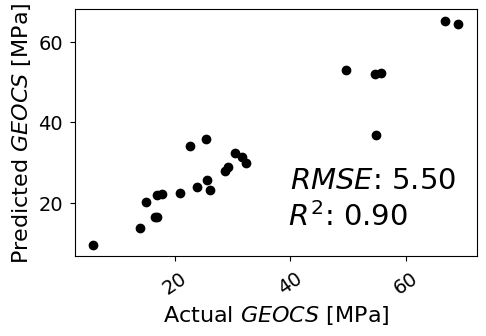

In [35]:
fig, ax1 = plt.subplots(1,1, figsize=(5,3.5))
# ###################################################################################################

ax1.scatter(y_test,Y_Test_Pred, 
            marker='o', color = 'black')

ax1.text(0.95, 0.25, ("$RMSE$: %0.02f" % rmse),
        verticalalignment='bottom', horizontalalignment='right',
        transform=ax1.transAxes,
        color='black', fontsize=21)

ax1.text(0.83, 0.1, ("$R^2$: %0.02f" % RSQ),
        verticalalignment='bottom', horizontalalignment='right',
        transform=ax1.transAxes,
        color='black', fontsize=21)


ax1.set_xlabel('Actual $GEO CS$ [MPa]', fontsize = 16)
ax1.tick_params(axis = "x", labelsize = 14, rotation=34)
ax1.xaxis.set_tick_params(pad=5)
ax1.set_ylabel('Predicted $GEO CS$ [MPa]', fontsize = 16)
ax1.tick_params(axis = "y", labelsize = 14)
ax1.yaxis.set_tick_params(pad=5)


plt.tight_layout(pad=1.2)
fig.savefig('Scatter_Plot_With_Tuning.jpg', format='jpeg', dpi=300, bbox_inches='tight')

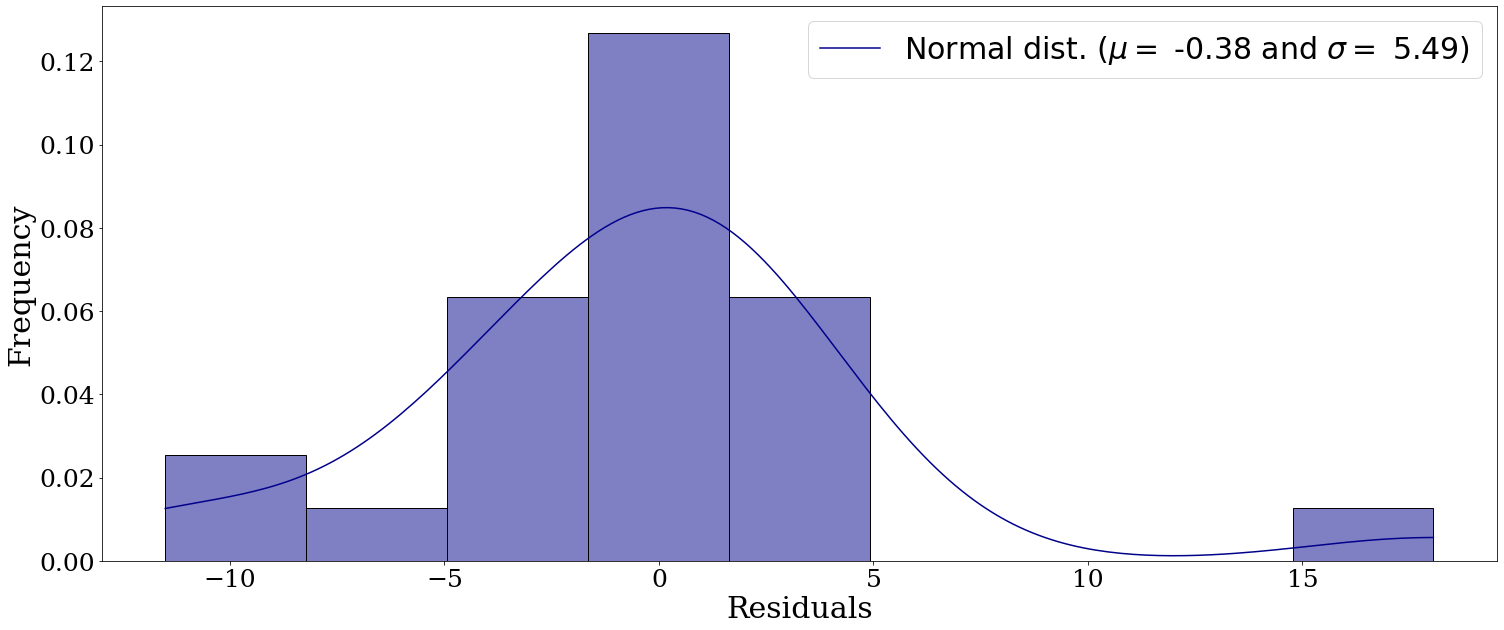

In [36]:
residuals = (y_test - Y_Test_Pred)
fig = plt.figure(figsize=(25, 10), dpi=72)
sns.histplot(residuals, kde=True, stat="density", color='darkblue')

(mu, sigma) = norm.fit(residuals)
plt.legend([r'Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f})'.format(mu, sigma)], loc='best', fontsize=30)
plt.xlabel('Residuals', fontsize=30, fontname='Serif')
plt.ylabel('Frequency', fontsize=30, fontname='Serif')
plt.xticks(fontsize=25, fontname='Serif')
plt.yticks(fontsize=25, fontname='Serif')
plt.figaspect(1.)
plt.title('')
# plt.savefig('Residual Distribution No Tuning.pdf')
plt.show()

## **Feature Importance**
Built-in from XGB Model

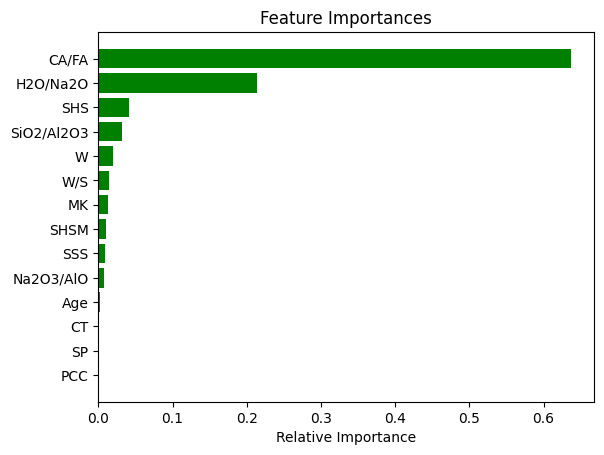

In [37]:
importances = model.feature_importances_
indices = np.argsort(importances)
x = Data_DF
features = x.columns
pyplot.title('Feature Importances')
pyplot.barh(range(len(indices)), importances[indices], color='g', align='center')
pyplot.yticks(range(len(indices)), [features[i] for i in indices])
pyplot.xlabel('Relative Importance')
pyplot.show()

## **PDP**

In [40]:
# Ensure X_train and X_test are DataFrames with the correct column names
X_train = pd.DataFrame(X_train, columns=Feature_Names)
X_test = pd.DataFrame(X_test, columns=Feature_Names)

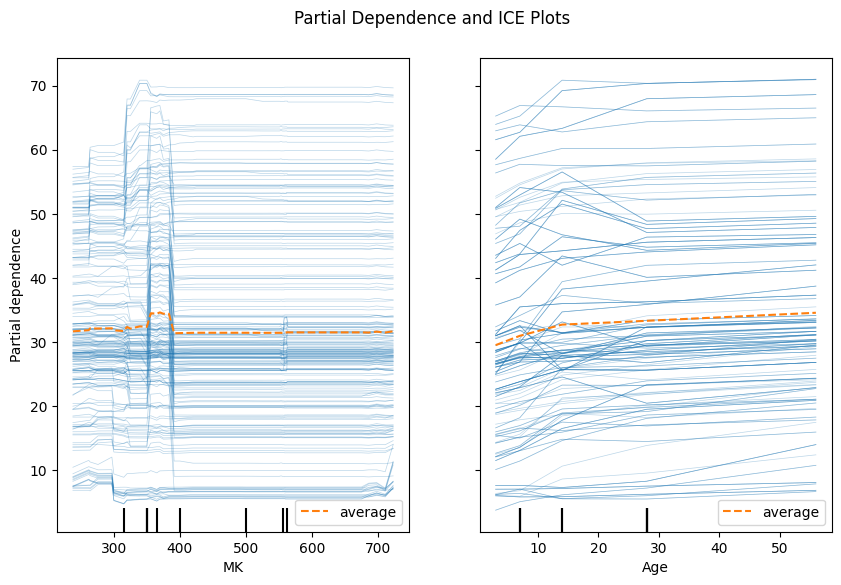

In [41]:
features_to_plot = features_to_plot = ['MK', 'Age']

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, X_train, features=features_to_plot, grid_resolution=50, kind='both', ax=ax)
plt.suptitle('Partial Dependence and ICE Plots')
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

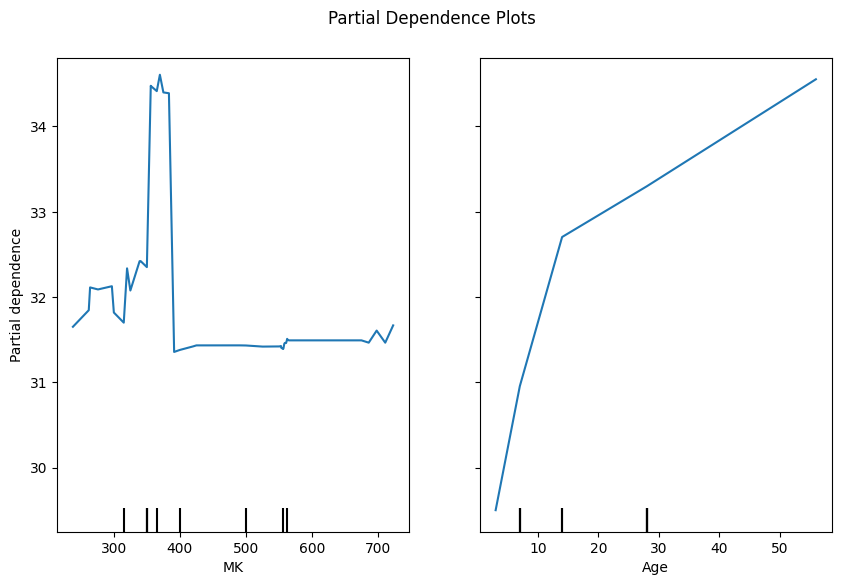

In [42]:
# Create Partial Dependence Plots
features_to_plot = ['MK', 'Age']  # Replace with your features of interest

fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(model, X_train, features=features_to_plot, grid_resolution=50, ax=ax)
plt.suptitle('Partial Dependence Plots')
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

## **LIME**


c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\buce_\AppData\Local\Programs\Python\Python312\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always 

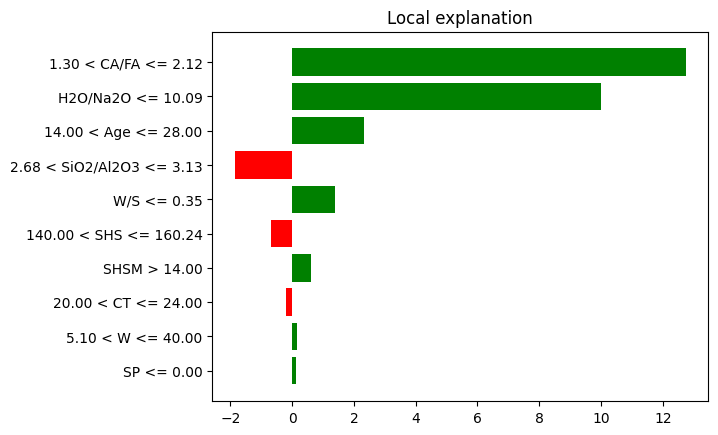

In [ ]:
# Adding LIME interpretation
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Compressive Strength'],
    mode='regression'
)

# Choose an instance from the test set to explain
instance_idx = 0
exp = explainer.explain_instance(
    data_row=X_test.iloc[instance_idx],
    predict_fn=model.predict
)

# Display the explanation
exp.show_in_notebook(show_table=True)
exp.as_pyplot_figure()
plt.show()

In [ ]:
instance_idx = 0
instance = X_test.iloc[instance_idx]
prediction = model.predict([instance])
print(f"Model prediction for instance {instance_idx}: {prediction[0]}")

Model prediction for instance 0: 52.053245544433594


## **SHAP**

In [ ]:
import shap
shap.initjs()

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Data_DF[Feature_Names].to_numpy())

df_shap_plot = Data_DF[['MK','SHS','SHSM','SSS','W','W/S','Na2O3/AlO','SiO2/Al2O3', 'H2O/Na2O', 'CA/FA', 'SP', 'PCC', 'CT','Age']].copy()
df_shap_plot.rename(columns = {
    'MK': '$MK$',     
    'SHS': '$SHS$',     
    'SHSM': '$SHSM$',    
    'SSS': '$SSS$',    
    'W': '$W$',       
    'W/S': '$W/S$',     
    'Na2O3/AlO': '$Na2O3/AlO$', 
    'SiO2/Al2O3': '$SiO2/Al2O3$', 
    'H2O/Na2O': '$H2O/Na2O$',    
    'CA/FA': '$CA/FA$',    
    'SP': '$SP$',      
    'PCC': '$PCC$',    
    'CT': '$CT$', 
    'Age': '$Age$'
}, inplace=True)

# Verify the column names
print(df_shap_plot.columns)

Index(['$MK$', '$SHS$', '$SHSM$', '$SSS$', '$W$', '$W/S$', '$Na2O3/AlO$',
       '$SiO2/Al2O3$', '$H2O/Na2O$', '$CA/FA$', '$SP$', '$PCC$', '$CT$',
       '$Age$'],
      dtype='object')


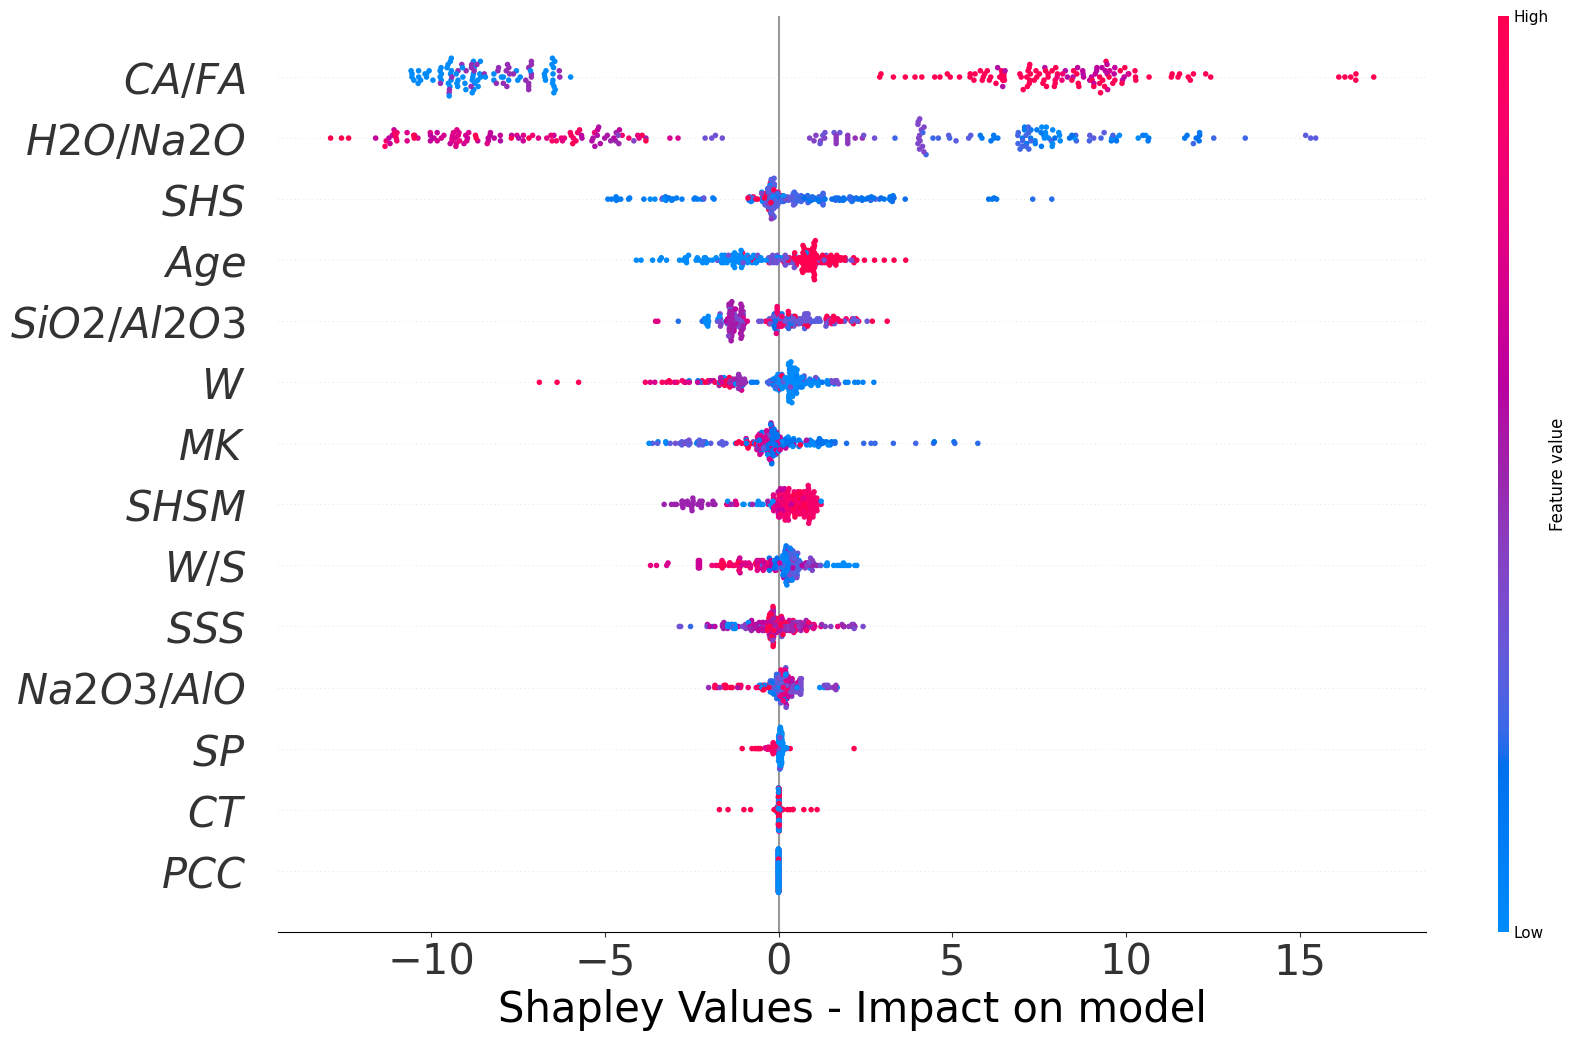

In [ ]:
# Define Features1 with the updated names
Features1 = ['$MK$', '$SHS$', '$SHSM$', '$SSS$', '$W$', '$W/S$', '$Na2O3/AlO$', '$SiO2/Al2O3$', '$H2O/Na2O$', '$CA/FA$', '$SP$', '$PCC$', '$CT$', '$Age$']

shap.summary_plot(shap_values, df_shap_plot[Features1].to_numpy(), Features1, plot_size=(16,10), show=False)
plt.xlabel('Shapley Values - Impact on model', fontsize=30)
plt.tick_params(labelsize=30)
plt.savefig('Feature Importance - SHAP.pdf', format='pdf', dpi=300, bbox_inches ='tight')

In [ ]:
shap.force_plot(explainer.expected_value, shap_values[0,:], Data_DF[Feature_Names].iloc[0,:],text_rotation=90)

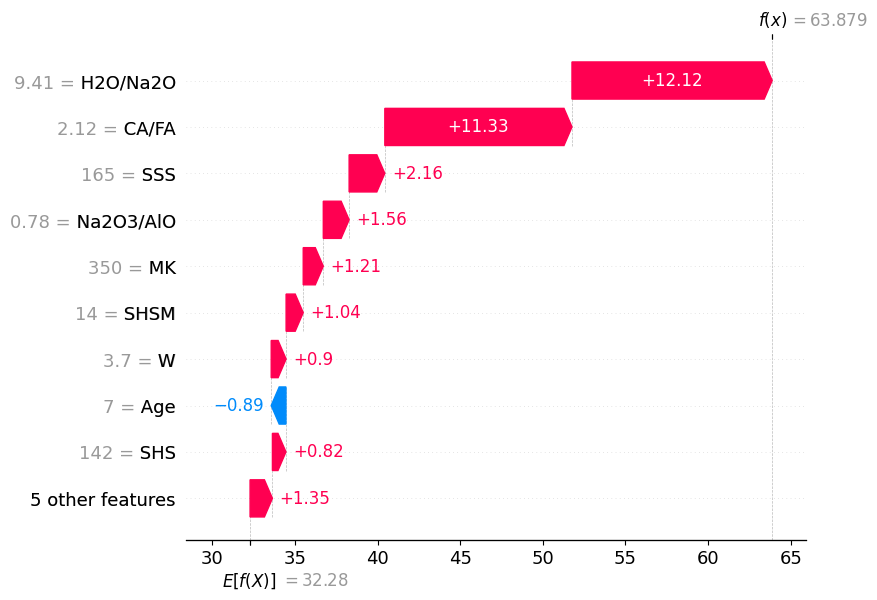

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Data_DF[Feature_Names].to_numpy())

if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=Data_DF.columns[:-1])


instance_index = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[instance_index],
    base_values=explainer.expected_value,
    data=Data_DF[Feature_Names].iloc[instance_index],
    feature_names=X_test.columns.tolist()
))

# Show the plot
plt.show()

In [ ]:
shap.force_plot(explainer.expected_value, shap_values, df_shap_plot[Features1].to_numpy())

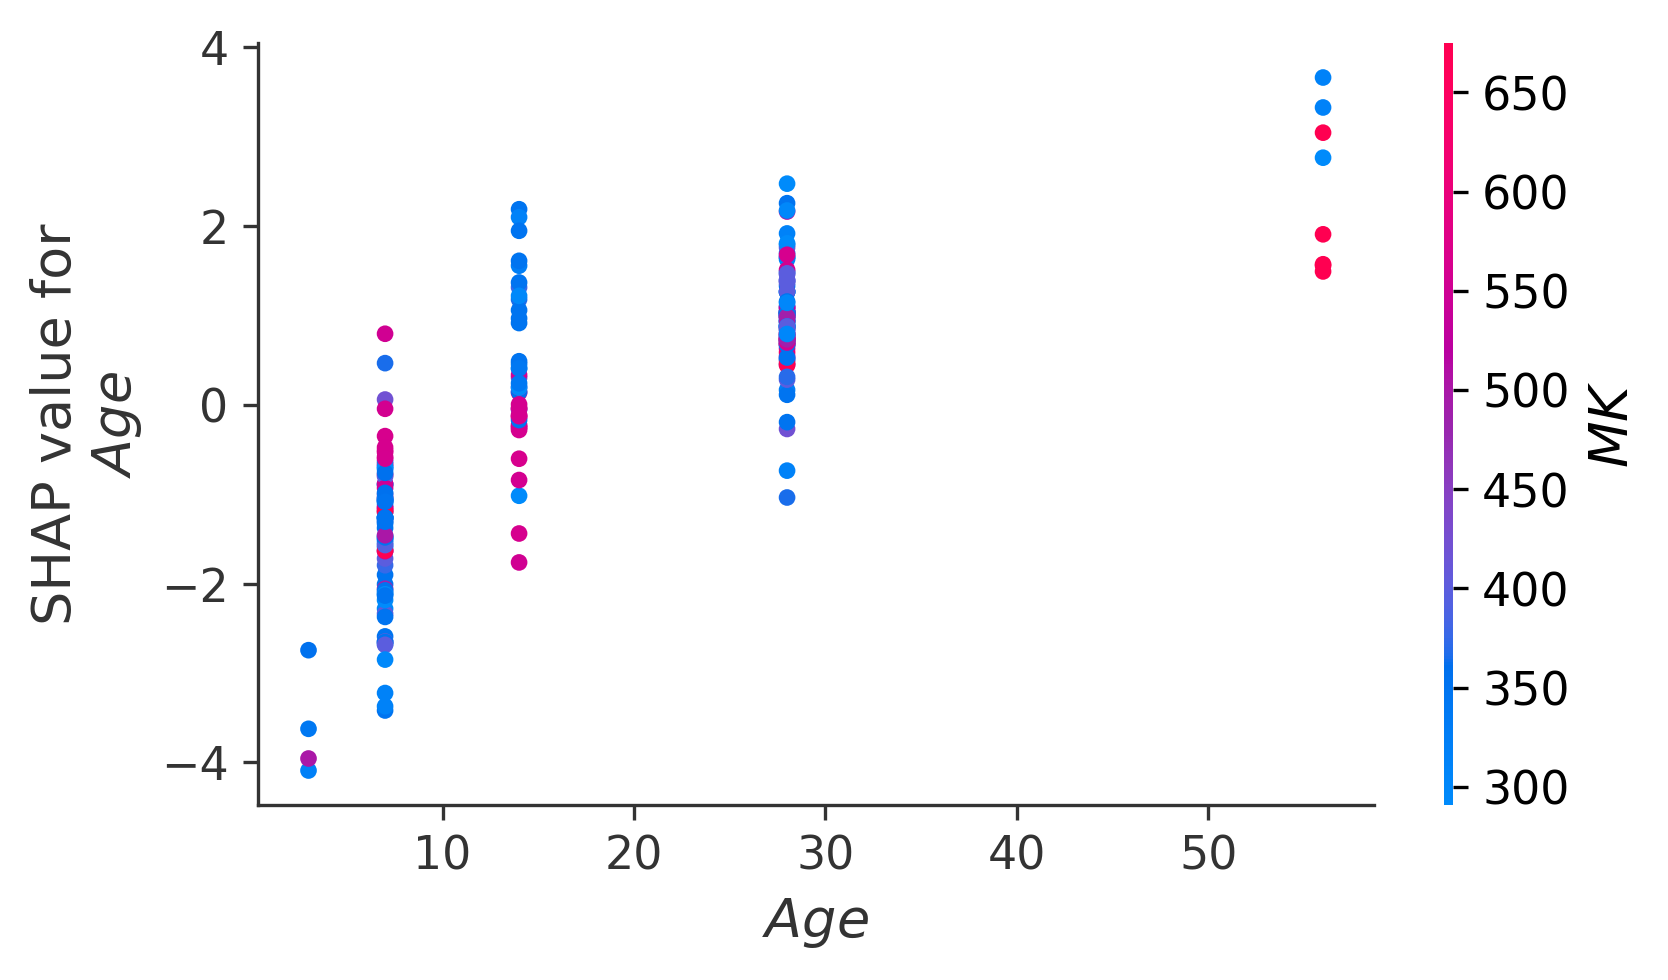

In [ ]:
fig = plt.figure(figsize=(6,3.3),dpi=300)
ax1 = fig.add_subplot(1,1,1)

shap.dependence_plot("$Age$",shap_values, df_shap_plot[Features1].to_numpy(),Features1, ax=ax1, show=False)

plt.savefig('Feature Interaction - Age vs. WB.jpg', format='jpeg', dpi=300, bbox_inches ='tight')

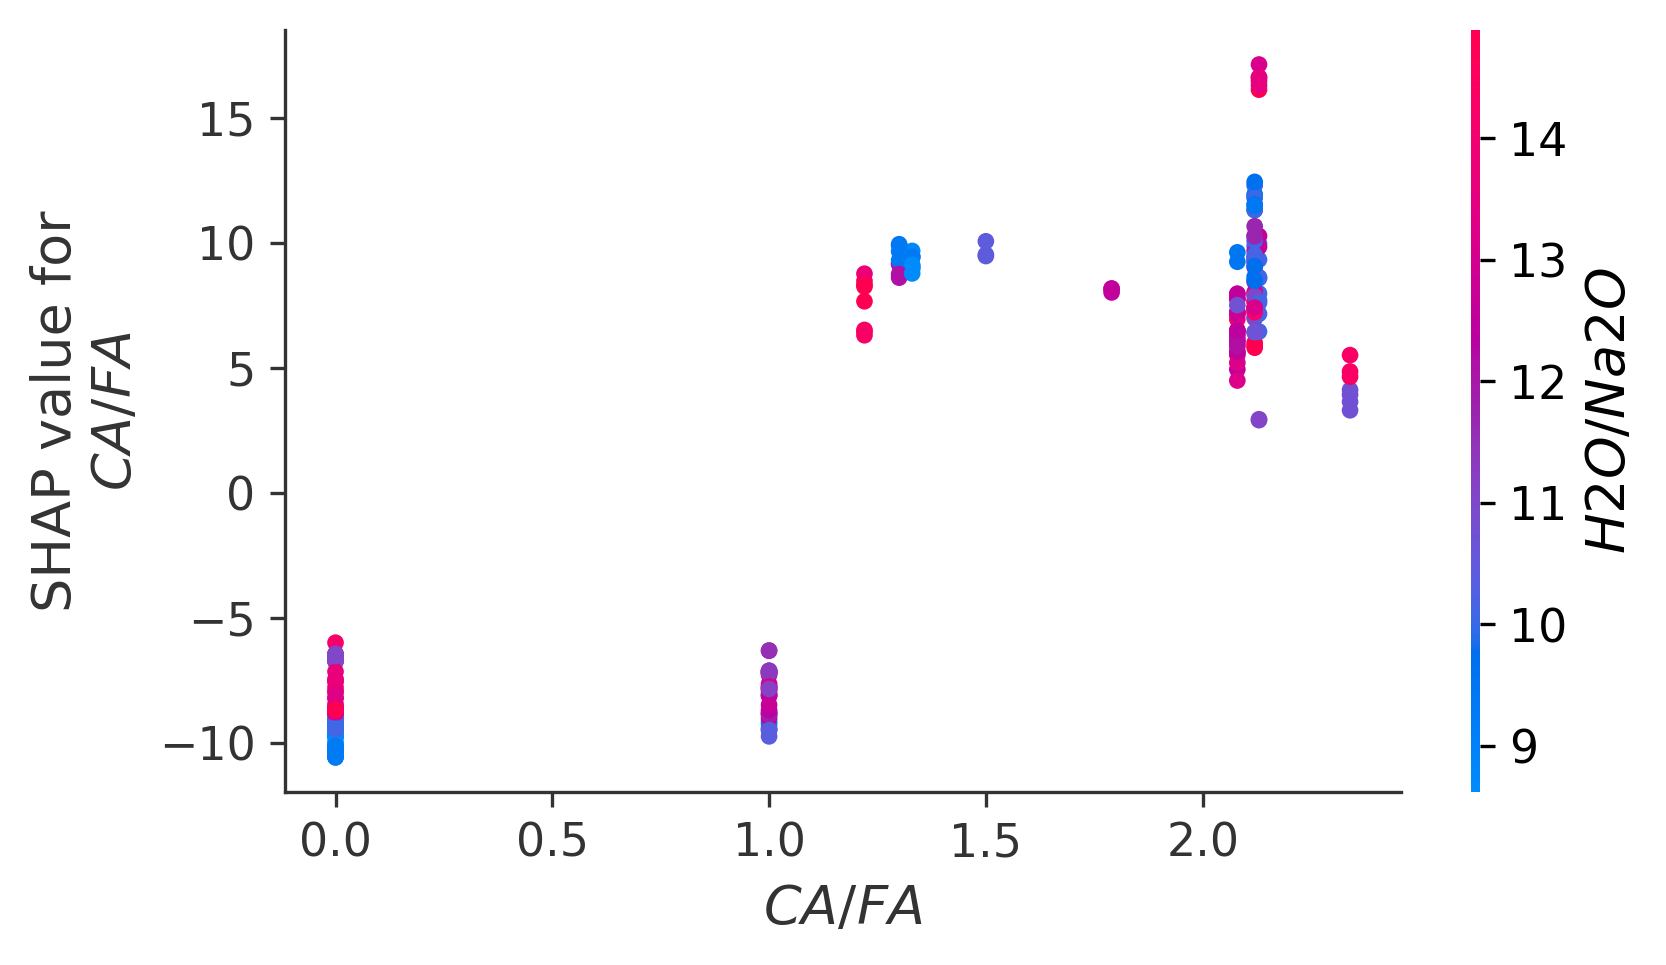

In [ ]:
fig = plt.figure(figsize=(6,3.3),dpi=300)
ax1 = fig.add_subplot(1,1,1)

shap.dependence_plot("$CA/FA$",shap_values, df_shap_plot[Features1].to_numpy(),Features1, ax=ax1, show=False)

plt.savefig('Feature Interaction - WB vs. C.jpg', format='jpeg', dpi=300, bbox_inches ='tight')

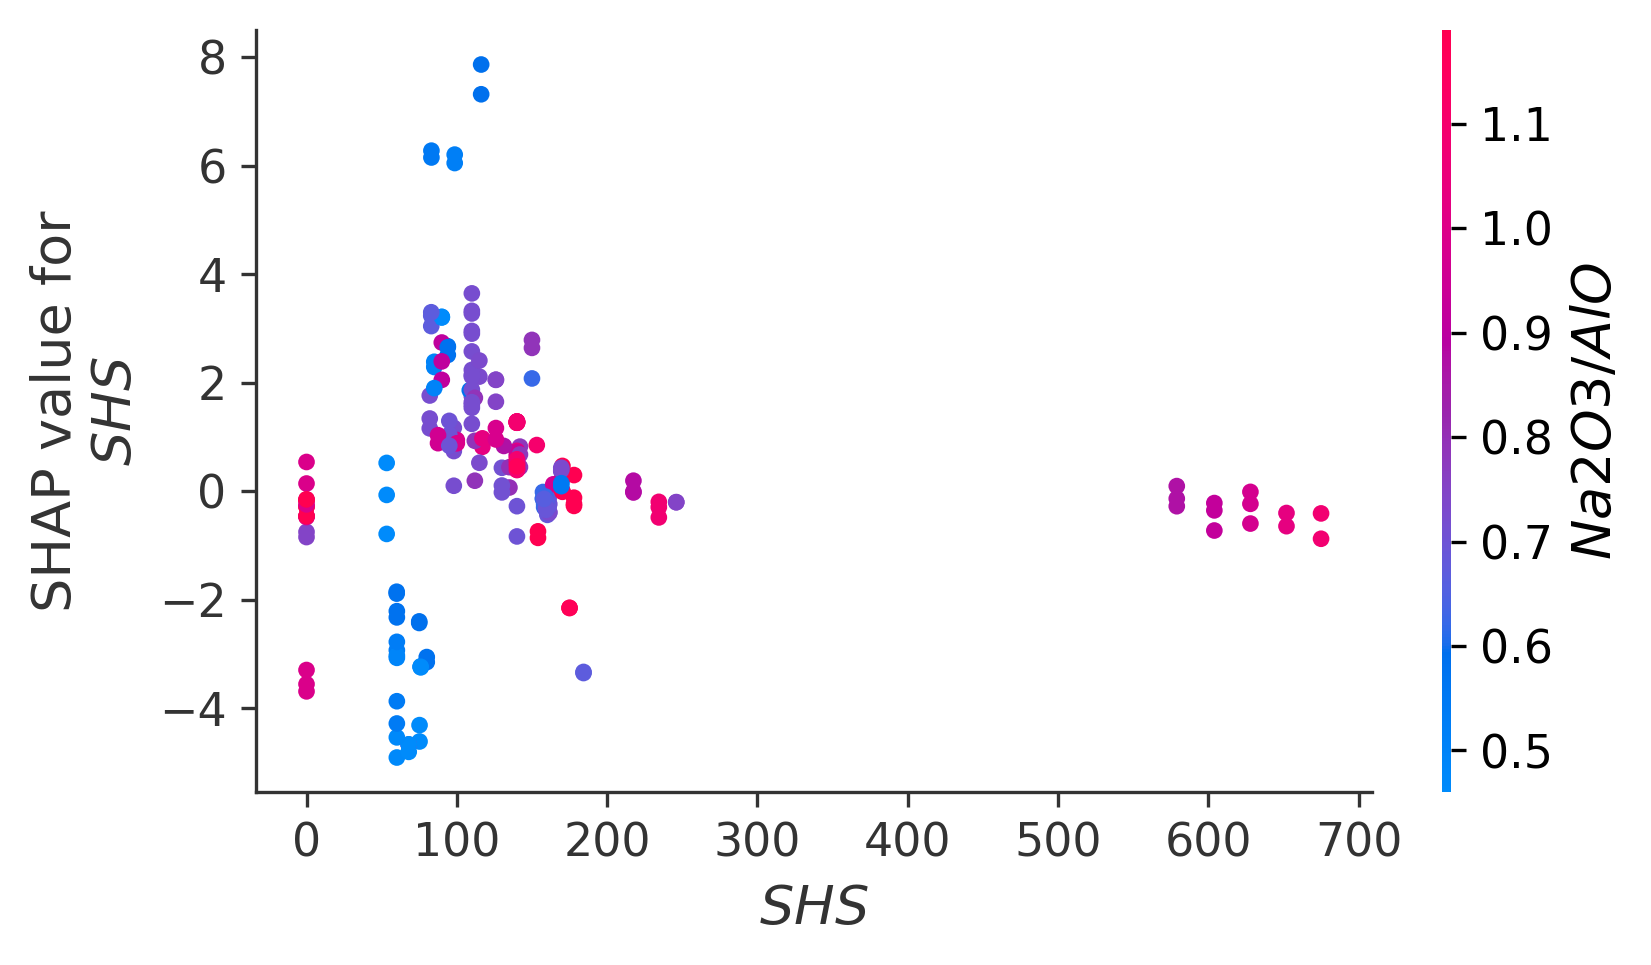

In [ ]:
fig = plt.figure(figsize=(6,3.3),dpi=300)
ax1 = fig.add_subplot(1,1,1)

shap.dependence_plot("$SHS$",shap_values, df_shap_plot[Features1].to_numpy(),Features1, ax=ax1, show=False)
plt.savefig('Feature Interaction - C vs. FA.jpg', format='jpeg', dpi=300, bbox_inches ='tight')